In [ ]:
!pip -q install timm gdown scikit-learn

In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Search for train/val/test folders
DRIVE_ROOT = "/content/drive/MyDrive"

ROOT = None

for dp, dn, files in os.walk(DRIVE_ROOT):
    if {"train", "val", "test"}.issubset(set(dn)):
        ROOT = dp
        break

assert ROOT is not None, \
    "Could not find train/val/test folders in Google Drive"

print("Dataset root:", ROOT)

for split in ["train", "val", "test"]:
    path = os.path.join(ROOT, split)
    print(split, "->", os.listdir(path))

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/dataset/MILK10k_Split
train -> ['GroundTruth.csv', 'Metadata.csv', 'Supplement_modified train.csv', 'images']
val -> ['GroundTruth.csv', 'Metadata.csv', 'Supplement_modified val.csv', 'images']
test -> ['GroundTruth.csv', 'Metadata.csv', 'Supplement_modified.csv', 'images']


In [ ]:
import os
import pandas as pd

# Split paths
TRAIN_DIR = os.path.join(ROOT, "train")
VAL_DIR   = os.path.join(ROOT, "val")
TEST_DIR  = os.path.join(ROOT, "test")

# CSV paths
TRAIN_GT = os.path.join(TRAIN_DIR, "GroundTruth.csv")
VAL_GT   = os.path.join(VAL_DIR, "GroundTruth.csv")
TEST_GT  = os.path.join(TEST_DIR, "GroundTruth.csv")

# Load GroundTruth
train_df = pd.read_csv(TRAIN_GT)
val_df   = pd.read_csv(VAL_GT)
test_df  = pd.read_csv(TEST_GT)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nGroundTruth columns:")
print(train_df.columns.tolist())

print("\nFirst 5 training rows:")
display(train_df.head())

# Image folders
TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, "images")
VAL_IMG_DIR   = os.path.join(VAL_DIR, "images")
TEST_IMG_DIR  = os.path.join(TEST_DIR, "images")

print("\nImage counts:")
print("Train images:", len(os.listdir(TRAIN_IMG_DIR)))
print("Val images:", len(os.listdir(VAL_IMG_DIR)))
print("Test images:", len(os.listdir(TEST_IMG_DIR)))

Train shape: (4192, 12)
Validation shape: (524, 12)
Test shape: (524, 12)

GroundTruth columns:
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

First 5 training rows:


,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IL_0003176,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IL_0004688,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IL_0006407,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IL_0008891,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



Image counts:
Train images: 8384
Val images: 1048
Test images: 1048


In [ ]:
import numpy as np

# Disease classes
CLASS_NAMES = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)


# Convert one-hot GroundTruth into class index
def get_class_label(row):
    values = row[CLASS_NAMES].values.astype(float)
    return int(np.argmax(values))


# Add numeric label
train_df["label"] = train_df.apply(get_class_label, axis=1)
val_df["label"]   = val_df.apply(get_class_label, axis=1)
test_df["label"]  = test_df.apply(get_class_label, axis=1)


# Add class name
train_df["class_name"] = train_df["label"].apply(
    lambda x: CLASS_NAMES[x]
)

val_df["class_name"] = val_df["label"].apply(
    lambda x: CLASS_NAMES[x]
)

test_df["class_name"] = test_df["label"].apply(
    lambda x: CLASS_NAMES[x]
)


# Class distribution
print("\nTrain class distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation class distribution:")
print(val_df["class_name"].value_counts())

print("\nTest class distribution:")
print(test_df["class_name"].value_counts())


# Sample
print("\nSample:")
display(
    train_df[["lesion_id", "label", "class_name"]].head()
)

Number of classes: 11
Classes: ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

Train class distribution:
class_name
BCC        2026
NV          577
BKL         431
SCCKA       392
MEL         365
AKIEC       247
INF          40
DF           38
BEN_OTH      35
VASC         34
MAL_OTH       7
Name: count, dtype: int64

Validation class distribution:
class_name
BCC        255
NV          81
BKL         58
MEL         43
SCCKA       40
AKIEC       25
INF          8
VASC         5
BEN_OTH      4
DF           3
MAL_OTH      2
Name: count, dtype: int64

Test class distribution:
class_name
BCC        241
NV          88
BKL         55
MEL         42
SCCKA       41
AKIEC       31
DF          11
VASC         8
BEN_OTH      5
INF          2
Name: count, dtype: int64

Sample:


,lesion_id,label,class_name
0,IL_0000652,1,BCC
1,IL_0003176,1,BCC
2,IL_0004688,1,BCC
3,IL_0006407,0,AKIEC
4,IL_0008891,8,NV


In [ ]:
import os
import glob

train_image_files = glob.glob(
    os.path.join(ROOT, "train", "images", "*")
)

print("First 20 image filenames:\n")

for path in train_image_files[:20]:
    print(os.path.basename(path))

First 20 image filenames:

ISIC_5476166.jpg
ISIC_7214986.jpg
ISIC_3122081.jpg
ISIC_7381318.jpg
ISIC_1943932.jpg
ISIC_2240759.jpg
ISIC_0250211.jpg
ISIC_9281043.jpg
ISIC_1664514.jpg
ISIC_8239142.jpg
ISIC_1642723.jpg
ISIC_1721747.jpg
ISIC_2925612.jpg
ISIC_4474700.jpg
ISIC_1217694.jpg
ISIC_5725725.jpg
ISIC_0881138.jpg
ISIC_9250781.jpg
ISIC_7878572.jpg
ISIC_8168496.jpg


In [ ]:
print("\nFirst 20 lesion IDs:\n")

for x in train_df["lesion_id"].astype(str).head(20):
    print(x)


First 20 lesion IDs:

IL_0000652
IL_0003176
IL_0004688
IL_0006407
IL_0008891
IL_0008969
IL_0009339
IL_0012199
IL_0014412
IL_0017483
IL_0019655
IL_0020208
IL_0024228
IL_0029019
IL_0030541
IL_0032270
IL_0039324
IL_0041758
IL_0044468
IL_0047878


In [ ]:
# ============================================================
# CELL 4 - 5 CLASS DATASET
# BCC, SCC, MELANOMA, NEVUS, KERATOSES
# ============================================================

import os
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image


# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

TRAIN_DIR = os.path.join(ROOT, "train")
VAL_DIR   = os.path.join(ROOT, "val")
TEST_DIR  = os.path.join(ROOT, "test")

TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, "images")
VAL_IMG_DIR   = os.path.join(VAL_DIR, "images")
TEST_IMG_DIR  = os.path.join(TEST_DIR, "images")


# ------------------------------------------------------------
# 2. Load CSV files
# ------------------------------------------------------------

train_gt = pd.read_csv(
    os.path.join(TRAIN_DIR, "GroundTruth.csv")
)

val_gt = pd.read_csv(
    os.path.join(VAL_DIR, "GroundTruth.csv")
)

test_gt = pd.read_csv(
    os.path.join(TEST_DIR, "GroundTruth.csv")
)

train_meta = pd.read_csv(
    os.path.join(TRAIN_DIR, "Metadata.csv")
)

val_meta = pd.read_csv(
    os.path.join(VAL_DIR, "Metadata.csv")
)

test_meta = pd.read_csv(
    os.path.join(TEST_DIR, "Metadata.csv")
)


# ------------------------------------------------------------
# 3. SELECT ONLY 5 CLASSES
# ------------------------------------------------------------

CLASS_NAMES = [
    "BCC",
    "SCCKA",
    "MEL",
    "NV",
    "BKL"
]

NUM_CLASSES = len(CLASS_NAMES)

print("================================")
print("SELECTED CLASSES")
print("================================")

for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

print("Number of classes:", NUM_CLASSES)


# ------------------------------------------------------------
# 4. Filter only selected classes
# ------------------------------------------------------------

def filter_classes(df):

    df = df.copy()

    # Keep only selected 5 classes
    df = df[
        df[CLASS_NAMES].sum(axis=1) > 0
    ].copy()

    # Convert one-hot label into 0-4
    df["label"] = df[CLASS_NAMES].values.argmax(axis=1)

    return df


train_gt = filter_classes(train_gt)
val_gt   = filter_classes(val_gt)
test_gt  = filter_classes(test_gt)


# ------------------------------------------------------------
# 5. Class distribution
# ------------------------------------------------------------

print("\n================================")
print("CLASS DISTRIBUTION")
print("================================")

for i, class_name in enumerate(CLASS_NAMES):

    train_count = (
        train_gt["label"] == i
    ).sum()

    val_count = (
        val_gt["label"] == i
    ).sum()

    test_count = (
        test_gt["label"] == i
    ).sum()

    print(
        f"{class_name:6s} -> "
        f"Train: {train_count:4d} | "
        f"Val: {val_count:3d} | "
        f"Test: {test_count:3d}"
    )


# ------------------------------------------------------------
# 6. Create image samples
# ------------------------------------------------------------

def create_samples(
    gt_df,
    meta_df,
    image_dir
):

    meta_small = meta_df[
        ["lesion_id", "isic_id"]
    ].copy()

    gt_df = gt_df.copy()

    gt_df["lesion_id"] = (
        gt_df["lesion_id"].astype(str)
    )

    meta_small["lesion_id"] = (
        meta_small["lesion_id"].astype(str)
    )

    meta_small["isic_id"] = (
        meta_small["isic_id"].astype(str)
    )

    # Connect:
    # GroundTruth lesion_id
    #        ↓
    # Metadata lesion_id
    #        ↓
    # ISIC image
    merged = pd.merge(
        gt_df[["lesion_id", "label"]],
        meta_small,
        on="lesion_id",
        how="inner"
    )

    samples = []

    for _, row in merged.iterrows():

        image_name = (
            row["isic_id"] + ".jpg"
        )

        image_path = os.path.join(
            image_dir,
            image_name
        )

        if os.path.exists(image_path):

            samples.append(
                (
                    image_path,
                    int(row["label"])
                )
            )

    return samples


# ------------------------------------------------------------
# 7. Create samples
# ------------------------------------------------------------

print("\nCreating datasets...")

train_samples = create_samples(
    train_gt,
    train_meta,
    TRAIN_IMG_DIR
)

val_samples = create_samples(
    val_gt,
    val_meta,
    VAL_IMG_DIR
)

test_samples = create_samples(
    test_gt,
    test_meta,
    TEST_IMG_DIR
)


# ------------------------------------------------------------
# 8. Dataset class
# ------------------------------------------------------------

class SkinLesionDataset(Dataset):

    def __init__(
        self,
        samples,
        transform=None
    ):

        self.samples = samples
        self.transform = transform

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# 9. Create datasets
# ------------------------------------------------------------

train_dataset = SkinLesionDataset(
    train_samples
)

val_dataset = SkinLesionDataset(
    val_samples
)

test_dataset = SkinLesionDataset(
    test_samples
)


# ------------------------------------------------------------
# 10. Summary
# ------------------------------------------------------------

print("\n================================")
print("5-CLASS DATASET SUMMARY")
print("================================")

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))


# ------------------------------------------------------------
# 11. Check first sample
# ------------------------------------------------------------

if len(train_dataset) > 0:

    image, label = train_dataset[0]

    print("\nFirst sample:")
    print("Image size:", image.size)
    print("Label:", label)
    print("Class:", CLASS_NAMES[label])
    print("Path:", train_samples[0][0])

SELECTED CLASSES
0 -> BCC
1 -> SCCKA
2 -> MEL
3 -> NV
4 -> BKL
Number of classes: 5

CLASS DISTRIBUTION
BCC    -> Train: 2026 | Val: 255 | Test: 241
SCCKA  -> Train:  392 | Val:  40 | Test:  41
MEL    -> Train:  365 | Val:  43 | Test:  42
NV     -> Train:  577 | Val:  81 | Test:  88
BKL    -> Train:  431 | Val:  58 | Test:  55

Creating datasets...

5-CLASS DATASET SUMMARY
Train: 7582
Val  : 954
Test : 934

First sample:
Image size: (600, 450)
Label: 0
Class: BCC
Path: /content/drive/MyDrive/dataset/MILK10k_Split/train/images/ISIC_8149219.jpg


In [ ]:
# ============================================================
# CELL 5 - TRANSFORMS + DATALOADERS
# ============================================================

from torchvision import transforms
from torch.utils.data import DataLoader


# ============================================================
# TRAIN TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# VALIDATION TRANSFORMS
# ============================================================

val_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# TEST TRANSFORMS
# ============================================================

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = SkinLesionDataset(
    train_samples,
    transform=train_transform
)

val_dataset = SkinLesionDataset(
    val_samples,
    transform=val_transform
)

test_dataset = SkinLesionDataset(
    test_samples,
    transform=test_transform
)


BATCH_SIZE = 16
NUM_WORKERS = 4


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)


# ============================================================
# CHECK DATA
# ============================================================

print("================================")
print("DATALOADER CHECK")
print("================================")

print("Train images :", len(train_dataset))
print("Val images   :", len(val_dataset))
print("Test images  :", len(test_dataset))

print("\nBatch size   :", BATCH_SIZE)
print("Workers      :", NUM_WORKERS)

print("\nTrain batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


# ============================================================
# TEST ONE BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\n================================")
print("BATCH TEST")
print("================================")

print("Image shape  :", images.shape)
print("Label shape  :", labels.shape)
print("Image dtype  :", images.dtype)
print("Label dtype  :", labels.dtype)

print("\n✓ DataLoader working correctly")

DATALOADER CHECK
Train images : 7582
Val images   : 954
Test images  : 934

Batch size   : 16
Workers      : 4

Train batches: 474
Val batches  : 60
Test batches : 59


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



BATCH TEST
Image shape  : torch.Size([16, 3, 224, 224])
Label shape  : torch.Size([16])
Image dtype  : torch.float32
Label dtype  : torch.int64

✓ DataLoader working correctly


In [ ]:
import time

print("TEST START")

start = time.time()

images, labels = next(iter(train_loader))

end = time.time()

print("BATCH LOADED")
print("Time taken:", round(end - start, 2), "seconds")

TEST START
BATCH LOADED
Time taken: 0.84 seconds


In [ ]:
# ============================================================
# CELL 6 - RESNET-50 MODEL
# 5 CLASS CLASSIFICATION
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# Load pretrained ResNet-50
weights = models.ResNet50_Weights.IMAGENET1K_V2

model = models.resnet50(weights=weights)

# Change final classifier from 1000 classes -> 5 classes
model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

# Move model to GPU/CPU
model = model.to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("\n================================")
print("RESNET-50 MODEL")
print("================================")
print("Number of classes :", NUM_CLASSES)
print("Classes           :", CLASS_NAMES)
print("Total parameters  :", f"{total_params:,}")
print("Trainable params  :", f"{trainable_params:,}")
print("Final classifier  :", model.fc)

Device: cuda

RESNET-50 MODEL
Number of classes : 5
Classes           : ['BCC', 'SCCKA', 'MEL', 'NV', 'BKL']
Total parameters  : 23,518,277
Trainable params  : 23,518,277
Final classifier  : Linear(in_features=2048, out_features=5, bias=True)


In [ ]:
# ============================================================
# CELL 7 - CLASS WEIGHTS + LOSS + OPTIMIZER + SCHEDULER
# ============================================================

import numpy as np
import torch.optim as optim

# ------------------------------------------------------------
# 1. Calculate class counts from training data
# ------------------------------------------------------------

class_counts = np.bincount(
    train_gt["label"].values,
    minlength=NUM_CLASSES
)

print("================================")
print("CLASS DISTRIBUTION")
print("================================")

for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:8s} : {class_counts[i]}")

# ------------------------------------------------------------
# 2. Calculate class weights
# ------------------------------------------------------------

total_samples = class_counts.sum()

class_weights = total_samples / (
    NUM_CLASSES * class_counts
)

print("\n================================")
print("CLASS WEIGHTS")
print("================================")

for i, class_name in enumerate(CLASS_NAMES):
    print(f"{class_name:8s} : {class_weights[i]:.4f}")

# Convert to PyTorch tensor
class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

# ------------------------------------------------------------
# 3. Loss function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ------------------------------------------------------------
# 4. Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.05
)

# ------------------------------------------------------------
# 5. Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

print("\n================================")
print("TRAINING SETTINGS")
print("================================")
print("Loss       : Weighted CrossEntropyLoss")
print("Optimizer  : AdamW")
print("Learning rate:", 0.0001)
print("Weight decay :", 0.05)
print("Scheduler  : ReduceLROnPlateau")

CLASS DISTRIBUTION
BCC      : 2026
SCCKA    : 392
MEL      : 365
NV       : 577
BKL      : 431

CLASS WEIGHTS
BCC      : 0.3742
SCCKA    : 1.9342
MEL      : 2.0773
NV       : 1.3140
BKL      : 1.7592

TRAINING SETTINGS
Loss       : Weighted CrossEntropyLoss
Optimizer  : AdamW
Learning rate: 0.0001
Weight decay : 0.05
Scheduler  : ReduceLROnPlateau


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
!nvidia-smi

Tue Oct  6 02:47:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             27W /   70W |    1447MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# ============================================================
# CELL 8 — TRAINING WITH CHECKPOINT + RESUME
# NO EARLY STOPPING
# ============================================================

import os
import time
import numpy as np
import torch
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EPOCHS = 100
BATCH_SIZE = 16

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

CHECKPOINT_DIR = "/content/drive/MyDrive/dataset/MILK10k_Split/checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LAST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "resnet50_last.pth"
)

BEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "resnet50_best.pth"
)

USE_AMP = torch.cuda.is_available()

print("Device:", DEVICE)
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Early Stopping: DISABLED")


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)


# ------------------------------------------------------------
# RESUME FROM LAST CHECKPOINT
# ------------------------------------------------------------

RESUME = True

start_epoch = 1
best_val_f1 = 0.0

if RESUME and os.path.exists(LAST_CHECKPOINT):

    print("\nLoading last checkpoint...")

    checkpoint = torch.load(
        LAST_CHECKPOINT,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        checkpoint["scheduler_state_dict"]
    )

    if USE_AMP and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(
            checkpoint["scaler_state_dict"]
        )

    start_epoch = checkpoint["epoch"] + 1

    best_val_f1 = checkpoint.get(
        "best_val_f1",
        0.0
    )

    print(
        "Last completed epoch:",
        checkpoint["epoch"]
    )

    print(
        "Best Validation Macro-F1:",
        f"{best_val_f1:.4f}"
    )

    print(
        "Resuming from epoch:",
        start_epoch
    )

else:

    print("\nNo checkpoint found.")
    print("Starting training from Epoch 1.")


# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

CLASS_NAMES = [
    "bcc",
    "scc",
    "melanoma",
    "nevus",
    "keratoses"
]


# ------------------------------------------------------------
# TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(start_epoch, EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss_total = 0.0

    train_targets = []
    train_preds = []

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{EPOCHS} - Train"
    )

    for images, labels in train_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss_total += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_targets.extend(
            labels.detach().cpu().numpy()
        )

        train_preds.extend(
            predictions.detach().cpu().numpy()
        )

    # --------------------------------------------------------
    # TRAIN METRICS
    # --------------------------------------------------------

    train_loss = (
        train_loss_total /
        len(train_dataset)
    )

    train_accuracy = accuracy_score(
        train_targets,
        train_preds
    )

    train_balanced_accuracy = balanced_accuracy_score(
        train_targets,
        train_preds
    )

    train_macro_precision = precision_score(
        train_targets,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_macro_recall = recall_score(
        train_targets,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_macro_f1 = f1_score(
        train_targets,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_weighted_precision = precision_score(
        train_targets,
        train_preds,
        average="weighted",
        zero_division=0
    )

    train_weighted_recall = recall_score(
        train_targets,
        train_preds,
        average="weighted",
        zero_division=0
    )

    train_weighted_f1 = f1_score(
        train_targets,
        train_preds,
        average="weighted",
        zero_division=0
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss_total = 0.0

    val_targets = []
    val_preds = []

    with torch.no_grad():

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch}/{EPOCHS} - Val"
        )

        for images, labels in val_bar:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            with torch.cuda.amp.autocast(
                enabled=USE_AMP
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            val_loss_total += (
                loss.item() * images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_targets.extend(
                labels.detach().cpu().numpy()
            )

            val_preds.extend(
                predictions.detach().cpu().numpy()
            )


    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    val_loss = (
        val_loss_total /
        len(val_dataset)
    )

    val_accuracy = accuracy_score(
        val_targets,
        val_preds
    )

    val_balanced_accuracy = balanced_accuracy_score(
        val_targets,
        val_preds
    )

    val_macro_precision = precision_score(
        val_targets,
        val_preds,
        average="macro",
        zero_division=0
    )

    val_macro_recall = recall_score(
        val_targets,
        val_preds,
        average="macro",
        zero_division=0
    )

    val_macro_f1 = f1_score(
        val_targets,
        val_preds,
        average="macro",
        zero_division=0
    )

    val_weighted_precision = precision_score(
        val_targets,
        val_preds,
        average="weighted",
        zero_division=0
    )

    val_weighted_recall = recall_score(
        val_targets,
        val_preds,
        average="weighted",
        zero_division=0
    )

    val_weighted_f1 = f1_score(
        val_targets,
        val_preds,
        average="weighted",
        zero_division=0
    )


    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(
        val_macro_f1
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    improved = (
        val_macro_f1 > best_val_f1
    )

    if improved:

        best_val_f1 = val_macro_f1

        print(
            "\n*** New Best Validation Macro-F1 ***"
        )


    # ========================================================
    # SAVE LAST CHECKPOINT
    # ========================================================

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "best_val_f1":
            best_val_f1,

        "val_macro_f1":
            val_macro_f1,

        "train_macro_f1":
            train_macro_f1
    }

    if USE_AMP:

        checkpoint[
            "scaler_state_dict"
        ] = scaler.state_dict()


    # Save every epoch

    torch.save(
        checkpoint,
        LAST_CHECKPOINT
    )


    # Save best model

    if improved:

        torch.save(
            checkpoint,
            BEST_CHECKPOINT
        )


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    epoch_time = (
        time.time() - epoch_start
    )

    print("\n")
    print("=" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("=" * 70)

    print("\nTRAIN METRICS")
    print("-" * 60)

    print(
        f"Train Loss              : {train_loss:.4f}"
    )

    print(
        f"Train Accuracy          : {train_accuracy:.4f}"
    )

    print(
        f"Train Balanced Accuracy : {train_balanced_accuracy:.4f}"
    )

    print(
        f"Train Macro Precision   : {train_macro_precision:.4f}"
    )

    print(
        f"Train Macro Recall      : {train_macro_recall:.4f}"
    )

    print(
        f"Train Macro F1          : {train_macro_f1:.4f}"
    )

    print(
        f"Train Weighted Precision: {train_weighted_precision:.4f}"
    )

    print(
        f"Train Weighted Recall   : {train_weighted_recall:.4f}"
    )

    print(
        f"Train Weighted F1       : {train_weighted_f1:.4f}"
    )


    print("\nVALIDATION METRICS")
    print("-" * 60)

    print(
        f"Val Loss                : {val_loss:.4f}"
    )

    print(
        f"Val Accuracy            : {val_accuracy:.4f}"
    )

    print(
        f"Val Balanced Accuracy   : {val_balanced_accuracy:.4f}"
    )

    print(
        f"Val Macro Precision     : {val_macro_precision:.4f}"
    )

    print(
        f"Val Macro Recall        : {val_macro_recall:.4f}"
    )

    print(
        f"Val Macro F1            : {val_macro_f1:.4f}"
    )

    print(
        f"Val Weighted Precision  : {val_weighted_precision:.4f}"
    )

    print(
        f"Val Weighted Recall     : {val_weighted_recall:.4f}"
    )

    print(
        f"Val Weighted F1         : {val_weighted_f1:.4f}"
    )


    print("\nPER-CLASS VALIDATION F1")

    print("-" * 60)

    per_class_f1 = f1_score(
        val_targets,
        val_preds,
        average=None,
        labels=np.arange(NUM_CLASSES),
        zero_division=0
    )

    for i, class_name in enumerate(CLASS_NAMES):

        print(
            f"{class_name:<15} : "
            f"{per_class_f1[i]:.4f}"
        )


    print(
        f"\nBest Validation Macro-F1: "
        f"{best_val_f1:.4f}"
    )

    print(
        f"Epoch Time: "
        f"{epoch_time / 60:.2f} minutes"
    )

    print(
        f"Last Checkpoint Saved: "
        f"{LAST_CHECKPOINT}"
    )

    if improved:

        print(
            f"Best Checkpoint Saved: "
            f"{BEST_CHECKPOINT}"
        )

    print("=" * 70)


# ============================================================
# TRAINING FINISHED
# ============================================================

print("\n")
print("=" * 70)
print("TRAINING FINISHED")
print("=" * 70)

print(
    f"Completed Epochs: "
    f"{start_epoch} to {EPOCHS}"
)

print(
    f"Best Validation Macro-F1: "
    f"{best_val_f1:.4f}"
)

print(
    f"Best Model: "
    f"{BEST_CHECKPOINT}"
)

Device: cuda
Epochs: 100
Batch Size: 16
Early Stopping: DISABLED

Loading last checkpoint...


/tmp/ipykernel_2237/939023594.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


Last completed epoch: 24
Best Validation Macro-F1: 0.6540
Resuming from epoch: 25


Epoch 25/100 - Train:   0%|          | 0/474 [00:00<?, ?it/s]

/tmp/ipykernel_2237/939023594.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


...

Epoch 100/100 - Train:   0%|          | 0/474 [00:00<?, ?it/s]

/tmp/ipykernel_2237/939023594.py:178: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Epoch 100/100 - Val:   0%|          | 0/60 [00:00<?, ?it/s]

/tmp/ipykernel_2237/939023594.py:304: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(




Epoch 100/100

TRAIN METRICS
------------------------------------------------------------
Train Loss              : 0.1168
Train Accuracy          : 0.9540
Train Balanced Accuracy : 0.9605
Train Macro Precision   : 0.9307
Train Macro Recall      : 0.9605
Train Macro F1          : 0.9448
Train Weighted Precision: 0.9560
Train Weighted Recall   : 0.9540
Train Weighted F1       : 0.9544

VALIDATION METRICS
------------------------------------------------------------
Val Loss                : 1.3169
Val Accuracy            : 0.7379
Val Balanced Accuracy   : 0.6709
Val Macro Precision     : 0.6360
Val Macro Recall        : 0.6709
Val Macro F1            : 0.6453
Val Weighted Precision  : 0.7681
Val Weighted Recall     : 0.7379
Val Weighted F1         : 0.7477

PER-CLASS VALIDATION F1
------------------------------------------------------------
bcc             : 0.8690
scc             : 0.5888
melanoma        : 0.5125
nevus           : 0.7215
keratoses       : 0.5348

Best Validation Macro

In [ ]:
# Check existing ResNet-50 checkpoint

import os
import torch

CHECKPOINT_PATH = "/content/drive/MyDrive/dataset/MILK10k_Split/checkpoints/resnet50_last.pth"

print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

if os.path.exists(CHECKPOINT_PATH):

    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )

    print("Last completed epoch:", checkpoint["epoch"])
    print("Best Validation Macro-F1:", checkpoint["best_val_f1"])

Checkpoint exists: True
Last completed epoch: 22
Best Validation Macro-F1: 0.6540157563675411


In [ ]:
# ============================================================
# CELL 9 - LOAD BEST MODEL
# ============================================================

BEST_CHECKPOINT = "/content/drive/MyDrive/dataset/MILK10k_Split/checkpoints/resnet50_best.pth"

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("================================")
print("BEST MODEL LOADED")
print("================================")

print("Best Epoch           :", checkpoint["epoch"])
print("Best Validation F1   :",
      f"{checkpoint['best_val_f1']:.4f}")

BEST MODEL LOADED
Best Epoch           : 12
Best Validation F1   : 0.6540


In [ ]:
# ============================================================
# CELL 10 - FINAL TEST EVALUATION
# ============================================================

import numpy as np
import torch
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

CLASS_NAMES_DISPLAY = [
    "BCC",
    "SCC",
    "Melanoma",
    "Nevus",
    "Keratoses"
]

# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

model.eval()

test_true = []
test_pred = []
test_loss = 0.0

with torch.no_grad():

    test_bar = tqdm(
        test_loader,
        desc="Testing",
        unit="batch"
    )

    for images, labels in test_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        test_loss += (
            loss.item() * images.size(0)
        )

        # Prediction
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_true.extend(
            labels.cpu().numpy()
        )

        test_pred.extend(
            predictions.cpu().numpy()
        )


# ------------------------------------------------------------
# TEST LOSS
# ------------------------------------------------------------

test_loss = test_loss / len(test_dataset)


# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_true,
    test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    test_true,
    test_pred
)

test_macro_precision = precision_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    test_true,
    test_pred,
    average="macro",
    zero_division=0
)

test_weighted_precision = precision_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

test_weighted_recall = recall_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

test_weighted_f1 = f1_score(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)


# ------------------------------------------------------------
# PRINT OVERALL RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("FINAL TEST RESULTS")
print("=" * 65)

print(f"Test Loss              : {test_loss:.4f}")
print(f"Test Accuracy          : {test_accuracy:.4f}")
print(f"Test Balanced Accuracy : {test_balanced_accuracy:.4f}")
print(f"Test Macro Precision   : {test_macro_precision:.4f}")
print(f"Test Macro Recall      : {test_macro_recall:.4f}")
print(f"Test Macro F1          : {test_macro_f1:.4f}")
print(f"Test Weighted Precision: {test_weighted_precision:.4f}")
print(f"Test Weighted Recall   : {test_weighted_recall:.4f}")
print(f"Test Weighted F1       : {test_weighted_f1:.4f}")


# ------------------------------------------------------------
# PER-CLASS REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 65)
print("PER-CLASS TEST METRICS")
print("=" * 65)

print(
    classification_report(
        test_true,
        test_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES_DISPLAY,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    test_true,
    test_pred,
    labels=np.arange(NUM_CLASSES)
)

print("\n")
print("=" * 65)
print("CONFUSION MATRIX")
print("=" * 65)

print("Rows    = Actual")
print("Columns = Predicted\n")

print(CLASS_NAMES_DISPLAY)
print(cm)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Testing:   0%|          | 0/59 [00:00<?, ?batch/s]



FINAL TEST RESULTS
Test Loss              : 1.2243
Test Accuracy          : 0.7323
Test Balanced Accuracy : 0.6352
Test Macro Precision   : 0.6260
Test Macro Recall      : 0.6352
Test Macro F1          : 0.6297
Test Weighted Precision: 0.7350
Test Weighted Recall   : 0.7323
Test Weighted F1       : 0.7331


PER-CLASS TEST METRICS
              precision    recall  f1-score   support

         BCC     0.8745    0.8527    0.8634       482
         SCC     0.5684    0.6585    0.6102        82
    Melanoma     0.5714    0.5238    0.5466        84
       Nevus     0.7213    0.7500    0.7354       176
   Keratoses     0.3945    0.3909    0.3927       110

    accuracy                         0.7323       934
   macro avg     0.6260    0.6352    0.6297       934
weighted avg     0.7350    0.7323    0.7331       934



CONFUSION MATRIX
Rows    = Actual
Columns = Predicted

['BCC', 'SCC', 'Melanoma', 'Nevus', 'Keratoses']
[[411  26   7  10  28]
 [ 13  54   1   0  14]
 [  4   0  44  26  10]
 [

<Figure size 800x700 with 0 Axes>

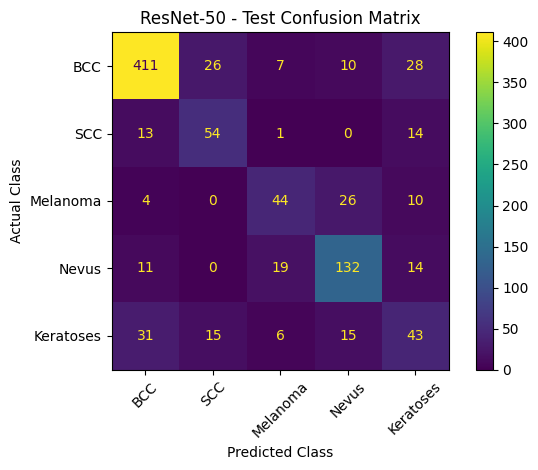

In [ ]:
# ============================================================
# CELL 11 - CONFUSION MATRIX VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ------------------------------------------------------------
# CONFUSION MATRIX DISPLAY
# ------------------------------------------------------------

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES_DISPLAY
)

disp.plot(
    values_format="d",
    xticks_rotation=45
)

plt.title("ResNet-50 - Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

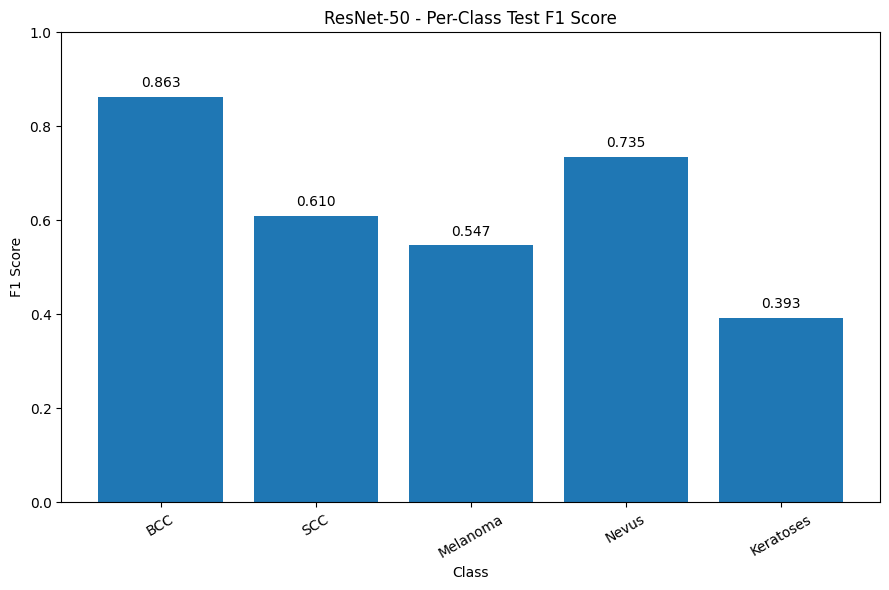

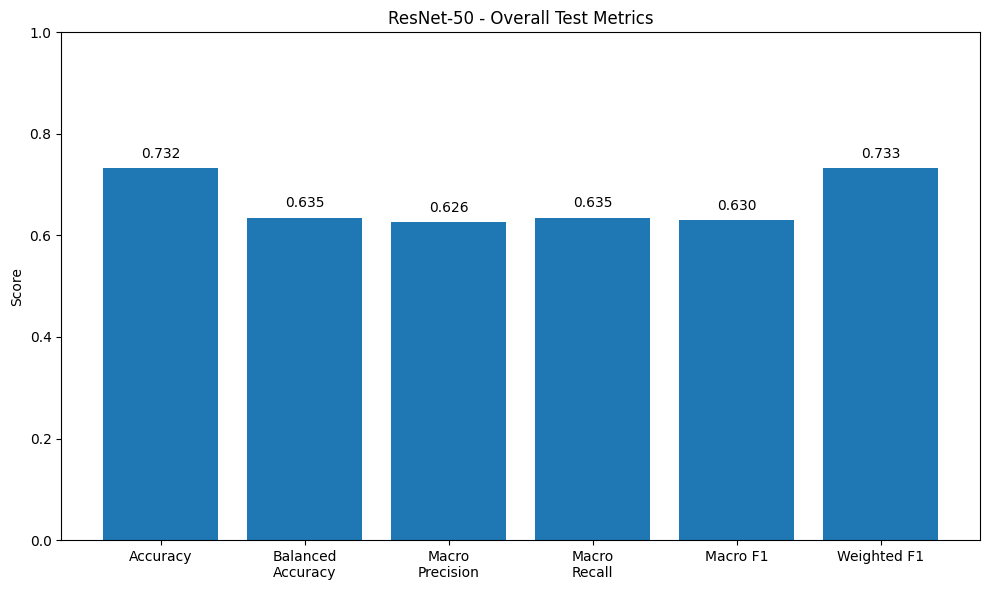

In [ ]:
# ============================================================
# CELL 12 - TEST METRICS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# PER-CLASS F1
# ------------------------------------------------------------

per_class_f1 = f1_score(
    test_true,
    test_pred,
    average=None,
    labels=np.arange(NUM_CLASSES),
    zero_division=0
)

plt.figure(figsize=(9, 6))

plt.bar(
    CLASS_NAMES_DISPLAY,
    per_class_f1
)

plt.ylim(0, 1)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("ResNet-50 - Per-Class Test F1 Score")

plt.xticks(rotation=30)

# Add values on bars
for i, value in enumerate(per_class_f1):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


# ============================================================
# OVERALL METRICS
# ============================================================

metric_names = [
    "Accuracy",
    "Balanced\nAccuracy",
    "Macro\nPrecision",
    "Macro\nRecall",
    "Macro F1",
    "Weighted F1"
]

metric_values = [
    test_accuracy,
    test_balanced_accuracy,
    test_macro_precision,
    test_macro_recall,
    test_macro_f1,
    test_weighted_f1
]

plt.figure(figsize=(10, 6))

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(0, 1)

plt.ylabel("Score")
plt.title("ResNet-50 - Overall Test Metrics")

for i, value in enumerate(metric_values):
    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Selected test images:
Class 0 (BCC) -> Dataset index 25
Class 1 (SCC) -> Dataset index 100
Class 2 (Melanoma) -> Dataset index 200
Class 3 (Nevus) -> Dataset index 300
Class 4 (Keratoses) -> Dataset index 400


Actual Class    : BCC
Predicted Class : BCC
Confidence      : 100.00%


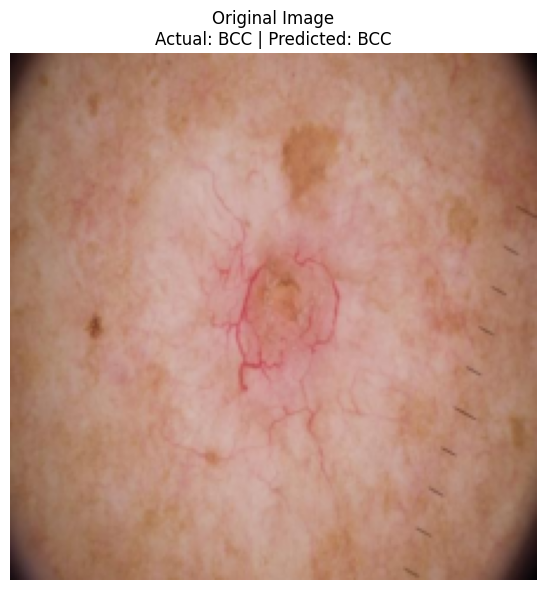

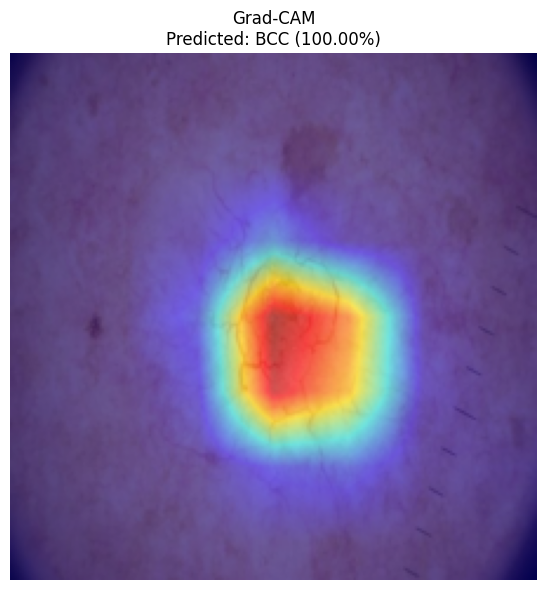



Actual Class    : Melanoma
Predicted Class : Melanoma
Confidence      : 100.00%


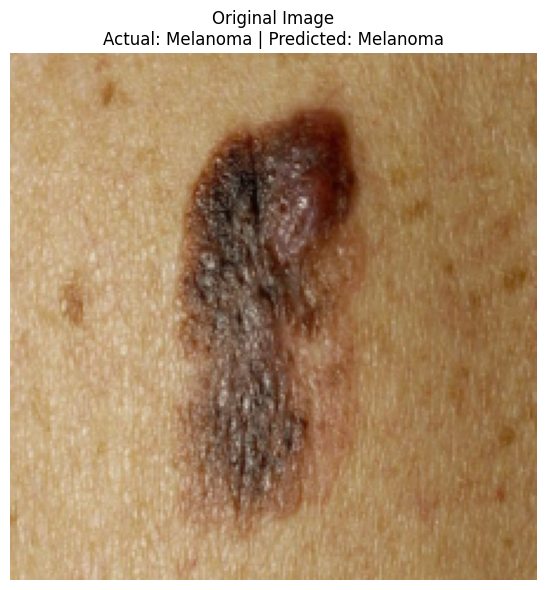

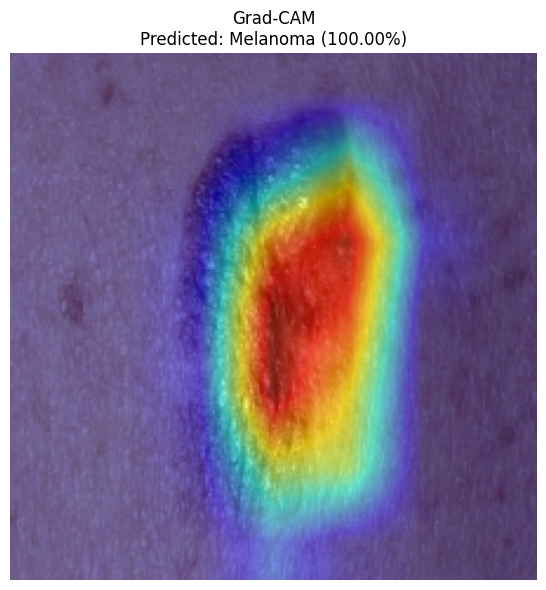



Actual Class    : BCC
Predicted Class : BCC
Confidence      : 99.27%


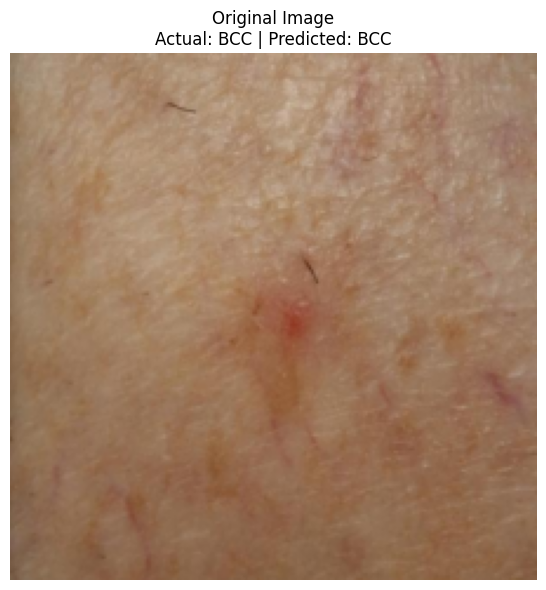

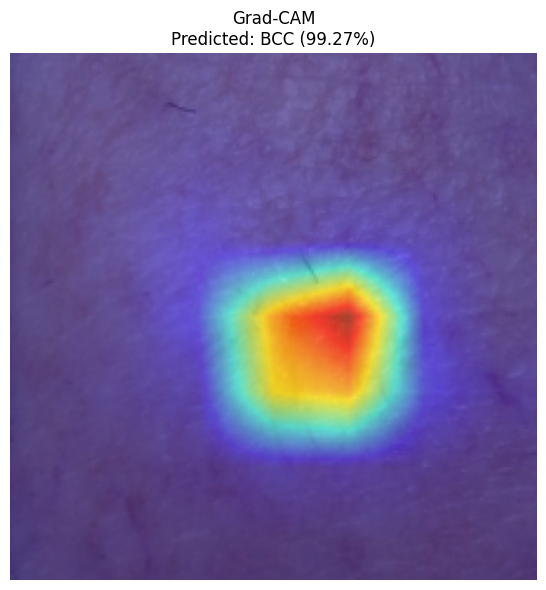



Actual Class    : Nevus
Predicted Class : Nevus
Confidence      : 99.54%


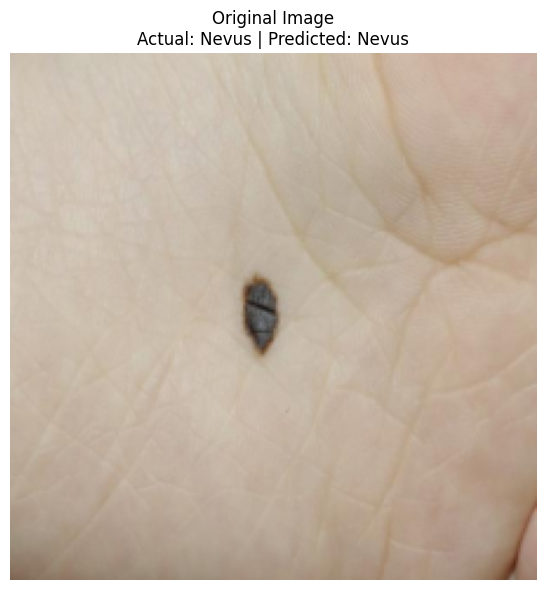

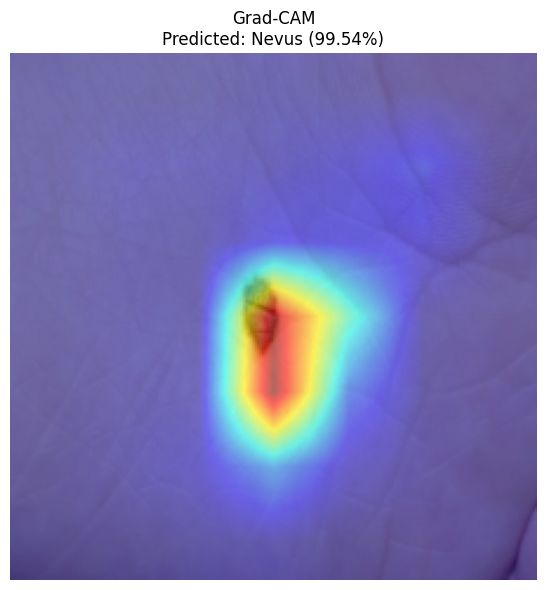



Actual Class    : Nevus
Predicted Class : Melanoma
Confidence      : 98.19%


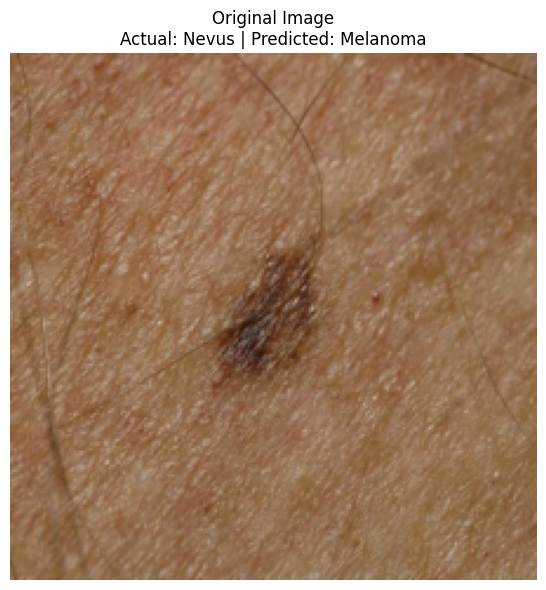

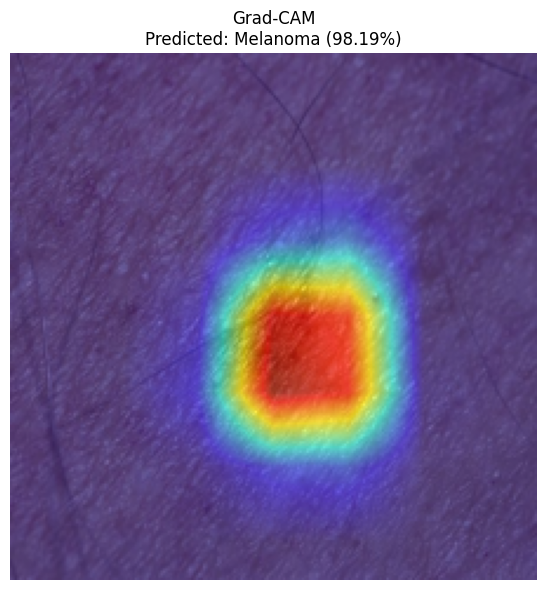

In [ ]:
# ============================================================
# CELL 13 - GRAD-CAM FOR 5 SKIN LESION CLASSES
# ============================================================

# Install Grad-CAM library
!pip install -q grad-cam


# ============================================================
# IMPORTS
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================
# SETTINGS
# ============================================================

model.eval()

CLASS_NAMES = [
    "BCC",
    "SCC",
    "Melanoma",
    "Nevus",
    "Keratoses"
]

NUM_CLASSES = 5


# ============================================================
# RESNET-50 TARGET LAYER
# ============================================================

# Last convolutional layer of ResNet-50
target_layers = [
    model.layer4[-1]
]


# ============================================================
# GRAD-CAM OBJECT
# ============================================================

cam = GradCAM(
    model=model,
    target_layers=target_layers
)


# ============================================================
# FUNCTION TO GET ONE IMAGE FROM EACH CLASS
# ============================================================

def get_one_image_per_class(dataset):

    selected = {}

    for index in range(len(dataset)):

        image, label = dataset[index]

        label = int(label)

        if label not in selected:

            selected[label] = index

        if len(selected) == NUM_CLASSES:
            break

    return selected


# ============================================================
# GET ONE TEST IMAGE FOR EACH CLASS
# ============================================================

# ============================================================
# GET ONE TEST IMAGE FOR EACH CLASS
# ============================================================

selected_images = {
    0: 25,    # BCC
    1: 100,   # SCC
    2: 200,   # Melanoma
    3: 300,   # Nevus
    4: 400    # Keratoses
}

print("Selected test images:")

for label, index in selected_images.items():

    print(
        f"Class {label} ({CLASS_NAMES[label]}) "
        f"-> Dataset index {index}"
    )


# ============================================================
# NORMALIZATION VALUES
# ============================================================

MEAN = np.array(
    [0.485, 0.456, 0.406],
    dtype=np.float32
)

STD = np.array(
    [0.229, 0.224, 0.225],
    dtype=np.float32
)


# ============================================================
# GRAD-CAM FOR EACH CLASS
# ============================================================

for true_label, index in selected_images.items():

    # --------------------------------------------------------
    # Get image
    # --------------------------------------------------------

    input_tensor, label = test_dataset[index]

    input_tensor = input_tensor.unsqueeze(0).to(DEVICE)

    true_label = int(label)


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_label = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_label
        ].item()


    # --------------------------------------------------------
    # Target class for Grad-CAM
    #
    # We visualize the class predicted by the model.
    # --------------------------------------------------------

    targets = [
        ClassifierOutputTarget(
            predicted_label
        )
    ]


    # --------------------------------------------------------
    # Generate CAM
    # --------------------------------------------------------

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

    grayscale_cam = grayscale_cam[0]


    # --------------------------------------------------------
    # Convert normalized tensor back to image
    # --------------------------------------------------------

    image = input_tensor[
        0
    ].detach().cpu().numpy()

    image = np.transpose(
        image,
        (1, 2, 0)
    )

    image = image * STD + MEAN

    image = np.clip(
        image,
        0,
        1
    )


    # --------------------------------------------------------
    # Create Grad-CAM overlay
    # --------------------------------------------------------

    visualization = show_cam_on_image(
        image,
        grayscale_cam,
        use_rgb=True
    )


    # ========================================================
    # DISPLAY
    # ========================================================

    print("\n")
    print("=" * 70)

    print(
        f"Actual Class    : "
        f"{CLASS_NAMES[true_label]}"
    )

    print(
        f"Predicted Class : "
        f"{CLASS_NAMES[predicted_label]}"
    )

    print(
        f"Confidence      : "
        f"{confidence * 100:.2f}%"
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Original Image
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(image)

    plt.title(
        f"Original Image\n"
        f"Actual: {CLASS_NAMES[true_label]} | "
        f"Predicted: {CLASS_NAMES[predicted_label]}"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()


    # --------------------------------------------------------
    # Grad-CAM
    # --------------------------------------------------------

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(visualization)

    plt.title(
        f"Grad-CAM\n"
        f"Predicted: {CLASS_NAMES[predicted_label]} "
        f"({confidence * 100:.2f}%)"
    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()